# Lecture #7: Feature Engineering & Selection

**Instructor:** Md. Samiul Islam | **Skill Morph Research Lab**  


## 📋 Lecture Plan

 Topic
-------
 Introduction: Why Feature Engineering & Selection matter
Creating New Features (domain knowledge, polynomial)
Filter Methods: Correlation, Chi-Square, Mutual Information
Wrapper Method: Recursive Feature Elimination (RFE)
Embedded Methods: Lasso & Tree-based Importance
Activity: Compare model with/without feature selection

## 📊 Datasets

**Lecture Dataset (Kaggle — June 2024):**
- **Employee Attrition Classification Dataset** by StealthTechnologies
- Link: https://www.kaggle.com/datasets/stealthtechnologies/employee-attrition-dataset
- Synthetic HR dataset, binary classification (Attrition: Yes/No), ~30 columns

**Assignment Dataset (Kaggle — Jan 2025):**
- **Employee Attrition Prediction Dataset** by ziya07
- Link: https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset
- Similar HR attrition theme, different features for independent practice

### Cell 1: Mount Drive & Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/datasets/employee_attrition_dataset.csv')
df.head()

Mounted at /content/drive


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


### Cell 2: Quick Look

In [6]:
df.shape

(1000, 26)

In [7]:
df.dtypes.value_counts()

,count
int64,20
object,6


### Cell 3: Encode Target & Select Numeric Features

In [8]:
from sklearn.preprocessing import LabelEncoder

# Encode target: Yes=1, No=0
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])

# Keep only numeric columns for simplicity
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Attrition')

X = df[num_cols]
y = df['Attrition']
X.columns.tolist()

['Employee_ID',
 'Age',
 'Job_Level',
 'Monthly_Income',
 'Hourly_Rate',
 'Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion',
 'Work_Life_Balance',
 'Job_Satisfaction',
 'Performance_Rating',
 'Training_Hours_Last_Year',
 'Project_Count',
 'Average_Hours_Worked_Per_Week',
 'Absenteeism',
 'Work_Environment_Satisfaction',
 'Relationship_with_Manager',
 'Job_Involvement',
 'Distance_From_Home',
 'Number_of_Companies_Worked']

### Cell 4: Feature Engineering — Domain Knowledge

In [10]:
# Feature 1: Annual income per year at company

X['income_per_year'] = (X['Monthly_Income'] * 12) / (X['Years_at_Company'] + 1)

# Feature 2: Loyalty ratio using number of companies worked
# Fewer companies = more loyal; inverse of job-hopping tendency
X['loyalty_ratio'] = X['Years_at_Company'] / (X['Number_of_Companies_Worked'] + 1)

X[['income_per_year', 'loyalty_ratio']].head()

,income_per_year,loyalty_ratio
0,11616.000000,3.75
1,22421.142857,2.00
2,6597.120000,6.00
3,7428.000000,2.50
4,4082.400000,7.25


### Cell 5: Feature Engineering — Polynomial Features

In [15]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_features = poly.fit_transform(X[['Age', 'Monthly_Income', 'Job_Satisfaction']])

feature_names = poly.get_feature_names_out(['Age', 'Monthly_Income', 'Job_Satisfaction'])
poly_df = pd.DataFrame(poly_features, columns=feature_names)

print(f"Shape: {poly_features.shape}")
print(f"Features: {list(feature_names)}\n")
print(poly_df.head())
print(poly_df.describe().round(2))

Shape: (1000, 6)
Features: ['Age', 'Monthly_Income', 'Job_Satisfaction', 'Age Monthly_Income', 'Age Job_Satisfaction', 'Monthly_Income Job_Satisfaction']

    Age  Monthly_Income  Job_Satisfaction  Age Monthly_Income  \
0  58.0         15488.0               3.0            898304.0   
1  48.0         13079.0               1.0            627792.0   
2  34.0         13744.0               2.0            467296.0   
3  27.0          6809.0               5.0            183843.0   
4  40.0         10206.0               5.0            408240.0   

   Age Job_Satisfaction  Monthly_Income Job_Satisfaction  
0                 174.0                          46464.0  
1                  48.0                          13079.0  
2                  68.0                          27488.0  
3                 135.0                          34045.0  
4                 200.0                          51030.0  
           Age  Monthly_Income  Job_Satisfaction  Age Monthly_Income  \
count  1000.00         1000.

### Cell 6: Filter Method — Correlation

Training_Hours_Last_Year        -0.0561
Years_Since_Last_Promotion      -0.0479
Performance_Rating              -0.0398
Job_Involvement                 -0.0373
Distance_From_Home              -0.0276
income_per_year                 -0.0162
Years_in_Current_Role           -0.0140
Hourly_Rate                     -0.0098
Employee_ID                     -0.0065
Number_of_Companies_Worked      -0.0011
Work_Environment_Satisfaction    0.0015
Project_Count                    0.0093
Job_Level                        0.0102
Monthly_Income                   0.0119
Job_Satisfaction                 0.0134
loyalty_ratio                    0.0159
Relationship_with_Manager        0.0160
Years_at_Company                 0.0229
Age                              0.0292
Work_Life_Balance                0.0334
Absenteeism                      0.0436
Average_Hours_Worked_Per_Week    0.0471


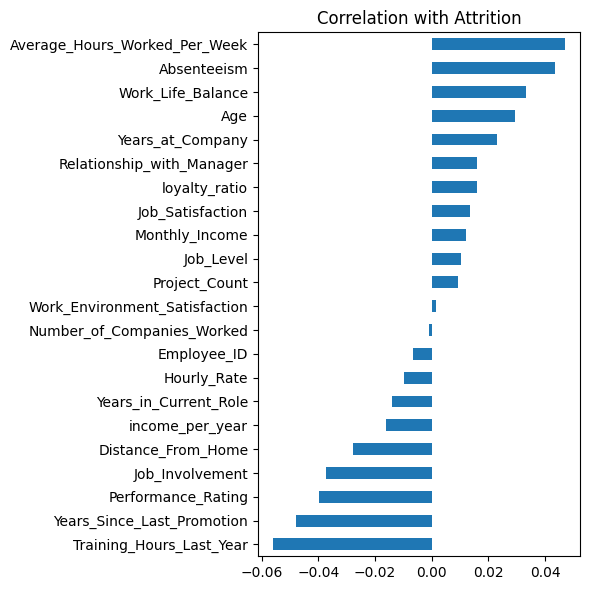

In [16]:
import matplotlib.pyplot as plt

# Add the newly engineered features from X to df so they can be used for correlation
df['income_per_year'] = X['income_per_year']
df['loyalty_ratio'] = X['loyalty_ratio']

corr = df[num_cols + ['income_per_year', 'loyalty_ratio', 'Attrition']].corr()['Attrition'].drop('Attrition').sort_values()
print(corr.round(4).to_string())
corr.plot(kind='barh', figsize=(6,6), title='Correlation with Attrition')
plt.tight_layout()
plt.show()

### Cell 7: Filter Method — Chi-Square Test

In [18]:
from sklearn.feature_selection import chi2, SelectKBest

# Chi-square needs non-negative values
X_pos = X - X.min()

chi_selector = SelectKBest(chi2, k=5)
chi_selector.fit(X_pos, y)

chi_scores = pd.Series(chi_selector.scores_, index=X.columns)
chi_scores.nlargest(5)

,0
income_per_year,5374.262055
Monthly_Income,404.459272
Training_Hours_Last_Year,49.972778
Average_Hours_Worked_Per_Week,11.545769
Employee_ID,7.123326


### Cell 8: Filter Method — Mutual Information

In [19]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.head(7)

,0
Training_Hours_Last_Year,0.026791
Years_at_Company,0.014485
Work_Life_Balance,0.010984
Monthly_Income,0.010204
Years_in_Current_Role,0.007267
Job_Satisfaction,0.006572
Job_Level,0.005572


### Cell 9: Wrapper Method — RFE

In [22]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=5)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_].tolist()
print("RFE selected:", rfe_features)

RFE selected: ['Employee_ID', 'Monthly_Income', 'Hourly_Rate', 'Training_Hours_Last_Year', 'income_per_year']


### Cell 10: Embedded Method — Lasso

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=42)
lasso.fit(X_scaled, y)

lasso_imp = pd.Series(abs(lasso.coef_[0]), index=X.columns)
print("Lasso non-zero features:")
print(lasso_imp[lasso_imp > 0].sort_values(ascending=False))

Lasso non-zero features:
Training_Hours_Last_Year         0.144391
Average_Hours_Worked_Per_Week    0.114494
Performance_Rating               0.103187
Absenteeism                      0.101533
Years_Since_Last_Promotion       0.098191
Job_Involvement                  0.093085
Work_Life_Balance                0.078025
Age                              0.065103
Distance_From_Home               0.062694
Years_at_Company                 0.044777
Hourly_Rate                      0.036086
Relationship_with_Manager        0.034581
Monthly_Income                   0.034559
Years_in_Current_Role            0.028699
income_per_year                  0.027030
Job_Level                        0.026576
Job_Satisfaction                 0.022346
Project_Count                    0.012175
Work_Environment_Satisfaction    0.006912
loyalty_ratio                    0.005256
Employee_ID                      0.000275
dtype: float64


### Cell 11: Embedded Method — Tree-based Importance

Monthly_Income                   0.0737
Employee_ID                      0.0713
Training_Hours_Last_Year         0.0699
Hourly_Rate                      0.0668
income_per_year                  0.0662
Distance_From_Home               0.0601
Average_Hours_Worked_Per_Week    0.0582
Age                              0.0567
loyalty_ratio                    0.0551
Absenteeism                      0.0515
Years_at_Company                 0.0494
Years_in_Current_Role            0.0479
Years_Since_Last_Promotion       0.0395
Project_Count                    0.0366
Job_Satisfaction                 0.0286
Job_Involvement                  0.0278
Job_Level                        0.0260
Performance_Rating               0.0243
Relationship_with_Manager        0.0238
Work_Environment_Satisfaction    0.0237
Work_Life_Balance                0.0228
Number_of_Companies_Worked       0.0200
dtype: float64


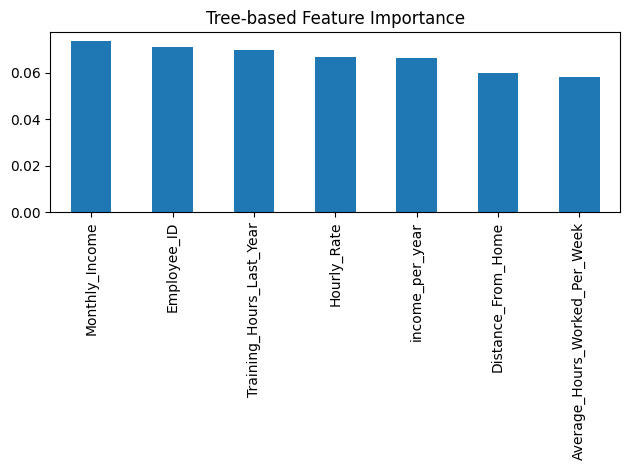

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(4))
imp.head(7).plot(kind='bar', title='Tree-based Feature Importance')
plt.tight_layout()
plt.show()

### Cell 12: Activity — Compare With vs Without Feature Selection

In [ ]:
from sklearn.model_selection import cross_val_score

# All features
score_all = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=5).mean()

# Top 5 features from RFE
score_rfe = cross_val_score(RandomForestClassifier(random_state=42), X[rfe_features], y, cv=5).mean()

# Top 5 from mutual info
top5_mi = mi_scores.head(5).index.tolist()
score_mi = cross_val_score(RandomForestClassifier(random_state=42), X[top5_mi], y, cv=5).mean()

results = pd.DataFrame({
    'Method': ['All Features', 'RFE (5)', 'Mutual Info (5)'],
    'Accuracy': [round(score_all,4), round(score_rfe,4), round(score_mi,4)]
})
results

,Method,Accuracy
0,All Features,0.811
1,RFE (5),0.717
2,Mutual Info (5),0.783


### Cell 13: Visual Comparison

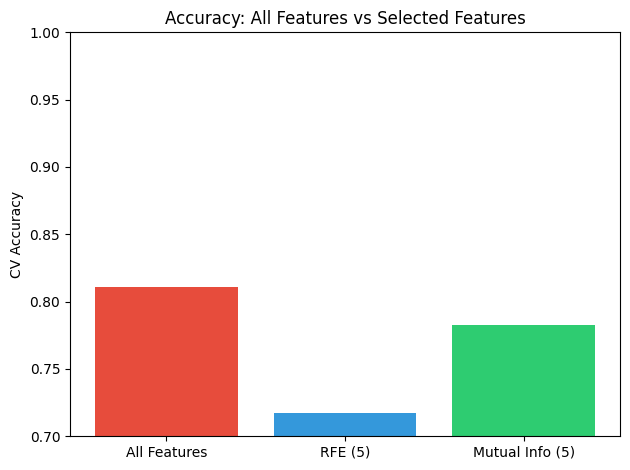

In [ ]:
plt.bar(results['Method'], results['Accuracy'], color=['#e74c3c','#3498db','#2ecc71'])
plt.ylim(0.7, 1.0)
plt.title('Accuracy: All Features vs Selected Features')
plt.ylabel('CV Accuracy')
plt.tight_layout()
plt.show()

## 📝 Assignment (Using Employee Attrition Prediction Dataset — Jan 2025)

**Dataset:** https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset

**Tasks:**

1. Load dataset from Drive, encode `Attrition` target, keep numeric columns.
2. Create 2 new features using domain knowledge (e.g., `satisfaction_per_year = JobSatisfaction / (YearsAtCompany+1)`).
3. Apply **correlation analysis** and **mutual information** to rank features.
4. Use **RFE** to select top 5 features.
5. Use **Lasso (L1)** and **Random Forest** to find important features.
6. Compare model accuracy: all features vs RFE-selected vs MI-selected (use `cross_val_score`).
7. Write a short summary (3–4 lines) on which method worked best and why.

**Submission:** `.ipynb` notebook via Google Colab link.

## 🔑 Key Takeaways

- Feature engineering creates new informative features from existing data
- Filter methods (correlation, chi-square, MI) are fast but ignore feature interactions
- Wrapper methods (RFE) consider model performance but are slower
- Embedded methods (Lasso, tree importance) do selection during training
- Fewer but better features often beat using all features

---

*Skill Morph Research Lab — Building ML Skills, One Lecture at a Time*